In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import re
from pathlib import Path
import difflib
import sys
from typing import Dict, Tuple, List, Optional

# ========= FIXED PATHS (Windows-friendly) =========
EXCEL_PATH = Path(r"C:\Users\bmwlab\Desktop\gen_tool\excel_relpace\cu_gnb_mod_report.xlsx")
CU_PATH    = Path(r"C:\Users\bmwlab\Desktop\gen_tool\excel_relpace\cu_gnb.conf")
DU_PATH    = Path(r"C:\Users\bmwlab\Desktop\gen_tool\excel_relpace\du_gnb.conf")
OUTDIR     = Path(r"C:\Users\bmwlab\Desktop\gen_tool\excel_relpace\excel_relpace")  # base output
SHEET_NAME = None  # set to a sheet name if needed; else None

# Subfolders
CONF_DIR   = OUTDIR / "confs"
DIFF_DIR   = OUTDIR / "diffs"
REPORT_DIR = OUTDIR / "reports"

# ========= BEHAVIOR =========
# - Each Excel ROW => a new modified CU/DU conf output (pair).
# - If a key exists in both CU and DU, modify CU and DO NOT modify DU for that key (prefer CU).
# - If a key exists only in DU, modify DU.
# - If a key exists in neither, it's recorded as not_found.

LINE_RE = re.compile(r'^\s*([A-Za-z0-9_]+)\s*=\s*(.+?)\s*;\s*$', re.MULTILINE)

def echo(msg: str):
    print(msg, file=sys.stdout, flush=True)

def parse_block_to_dict(block: str) -> Dict[str, str]:
    """Parse lines of the form 'key = value;' into a dict."""
    out = {}
    for m in LINE_RE.finditer(block or ""):
        key = m.group(1)
        value = m.group(2).strip()
        out[key] = value
    return out

def load_df_from_path(path: Path, sheet_name=None):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    suff = path.suffix.lower()
    import pandas as pd
    if suff in (".xlsx", ".xls"):
        try:
            df = pd.read_excel(path, sheet_name=sheet_name, engine="openpyxl")
        except ImportError as e:
            raise ImportError("Reading .xlsx requires openpyxl. Install: pip install openpyxl") from e
        except Exception:
            df = pd.read_excel(path, sheet_name=sheet_name)
        if isinstance(df, dict):  # sheet_name=None returns dict
            first = next(iter(df.keys()))
            echo(f"[INFO] Multiple sheets detected; using first: {first!r}")
            df = df[first]
        return df
    elif suff == ".csv":
        return pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported Excel file '{path.name}'. Use .xlsx/.xls/.csv.")

def find_modified_col(df) -> Optional[str]:
    for c in df.columns:
        if "modified" in str(c).lower():
            return c
    return None

def find_label_col(df) -> Optional[str]:
    candidates = ["name","label","id","case","title","tag","index"]
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for cand in candidates:
        if cand in lower_map:
            return lower_map[cand]
    return None

def sanitize_for_filename(s: str) -> str:
    s = s.strip()
    if not s:
        return ""
    bad = '<>:"/\\|?*'
    for ch in bad:
        s = s.replace(ch, "_")
    return s[:80]

def replace_key_value_in_conf(conf_text: str, key: str, new_value: str) -> Tuple[str, bool, str]:
    """Replace last occurrence of key's value in conf_text and return (new_text, changed?, old_value)."""
    pattern = re.compile(rf'(^\s*{re.escape(key)}\s*=\s*)([^;]*)(;\s*$)', re.MULTILINE)
    matches = list(pattern.finditer(conf_text))
    if not matches:
        return conf_text, False, ""
    m = matches[-1]
    old_value = m.group(2).strip()
    start, end = m.span()
    new_segment = f"{m.group(1)}{new_value}{m.group(3)}"
    new_text = conf_text[:start] + new_segment + conf_text[end:]
    return new_text, True, old_value

def write_diff(old_text: str, new_text: str, fromfile: str, tofile: str) -> str:
    diff = difflib.unified_diff(
        old_text.splitlines(keepends=True),
        new_text.splitlines(keepends=True),
        fromfile=fromfile,
        tofile=tofile,
        n=3
    )
    return "".join(diff)

def main():
    # Ensure subfolders
    for d in (OUTDIR, CONF_DIR, DIFF_DIR, REPORT_DIR):
        d.mkdir(parents=True, exist_ok=True)

    # Load base CU/DU
    try:
        cu_base = CU_PATH.read_text(encoding="utf-8", errors="ignore")
    except Exception as e:
        echo(f"[ERROR] Cannot read CU conf: {CU_PATH} ; {e}")
        sys.exit(1)
    try:
        du_base = DU_PATH.read_text(encoding="utf-8", errors="ignore")
    except Exception as e:
        echo(f"[ERROR] Cannot read DU conf: {DU_PATH} ; {e}")
        sys.exit(1)

    # Load Excel
    try:
        df = load_df_from_path(EXCEL_PATH, sheet_name=SHEET_NAME)
    except Exception as e:
        echo(f"[ERROR] Cannot read Excel: {EXCEL_PATH} ; {e}")
        sys.exit(1)

    echo(f"[INFO] Columns: {list(df.columns)}")
    mod_col = find_modified_col(df)
    if mod_col is None:
        echo("[ERROR] No column containing 'Modified' found. Add a column named like 'Modified' or 'Modified EX'.")
        sys.exit(1)

    label_col = find_label_col(df)
    if label_col:
        echo(f"[INFO] Label column detected: {label_col!r}")
    else:
        echo("[INFO] No label column found. Using row indices in filenames.")

    # Master index report
    master_rows = []

    # Process rows
    for idx, row in df.iterrows():
        block = str(row.get(mod_col, "") or "")
        mods = parse_block_to_dict(block)

        cu_new = cu_base
        du_new = du_base
        per_records = []

        for key, new_val in mods.items():
            cu_replaced_text, cu_changed, cu_old = replace_key_value_in_conf(cu_new, key, new_val)
            if cu_changed:
                cu_new = cu_replaced_text
                per_records.append({"param": key, "target": "CU", "old_value": cu_old, "new_value": new_val, "status": "modified"})
                continue
            du_replaced_text, du_changed, du_old = replace_key_value_in_conf(du_new, key, new_val)
            if du_changed:
                du_new = du_replaced_text
                per_records.append({"param": key, "target": "DU", "old_value": du_old, "new_value": new_val, "status": "modified"})
            else:
                per_records.append({"param": key, "target": "-", "old_value": "", "new_value": new_val, "status": "not_found_in_both"})

        label_val = str(row.get(label_col, "")).strip() if label_col else ""
        suffix = sanitize_for_filename(label_val) or f"row{idx+1:03d}"

        # Write confs
        cu_out = CONF_DIR / f"{CU_PATH.stem}.{suffix}.modified.conf"
        du_out = CONF_DIR / f"{DU_PATH.stem}.{suffix}.modified.conf"
        cu_out.write_text(cu_new, encoding="utf-8")
        du_out.write_text(du_new, encoding="utf-8")

        # Write diffs
        cu_diff = write_diff(cu_base, cu_new, CU_PATH.name, cu_out.name)
        du_diff = write_diff(du_base, du_new, DU_PATH.name, du_out.name)
        (DIFF_DIR / f"{CU_PATH.stem}.{suffix}.diff.txt").write_text(cu_diff, encoding="utf-8")
        (DIFF_DIR / f"{DU_PATH.stem}.{suffix}.diff.txt").write_text(du_diff, encoding="utf-8")

        # Per-row CSV
        try:
            import csv
            per_csv = REPORT_DIR / f"mod_report.{suffix}.csv"
            with per_csv.open("w", newline="", encoding="utf-8") as f:
                writer = csv.DictWriter(f, fieldnames=["param","target","old_value","new_value","status"])
                writer.writeheader()
                writer.writerows(per_records)
        except Exception as e:
            echo(f"[WARN] Failed to write per-row CSV for {suffix}: {e}")

        modified_cnt = sum(1 for r in per_records if r["status"] == "modified")
        not_found_cnt = sum(1 for r in per_records if r["status"] == "not_found_in_both")
        master_rows.append({
            "row_index": idx+1,
            "suffix": suffix,
            "modified_count": modified_cnt,
            "not_found_count": not_found_cnt,
            "cu_conf": str(cu_out),
            "du_conf": str(du_out),
        })

        echo(f"[OK] Row {idx+1}: wrote confs -> {cu_out.name}, {du_out.name}; diffs -> {CU_PATH.stem}.{suffix}.diff.txt, {DU_PATH.stem}.{suffix}.diff.txt")

    # Master CSV
    try:
        import csv
        master_csv = REPORT_DIR / "mod_report.master.csv"
        with master_csv.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=["row_index","suffix","modified_count","not_found_count","cu_conf","du_conf"])
            writer.writeheader()
            writer.writerows(master_rows)
        echo(f"[OK] Master report: {master_csv}")
    except Exception as e:
        echo(f"[WARN] Failed to write master CSV: {e}")

if __name__ == "__main__":
    main()

[INFO] Multiple sheets detected; using first: 'Sheet1'
[INFO] Columns: ['Key', '原始參數 / Original', '修改參數 / Modified', '輸出檔名 / Output File']
[INFO] No label column found. Using row indices in filenames.
[OK] Row 1: wrote cu_gnb.row001.modified.conf, du_gnb.row001.modified.conf (mods: 1, missing: 0)
[OK] Row 2: wrote cu_gnb.row002.modified.conf, du_gnb.row002.modified.conf (mods: 1, missing: 0)
[OK] Row 3: wrote cu_gnb.row003.modified.conf, du_gnb.row003.modified.conf (mods: 1, missing: 0)
[OK] Row 4: wrote cu_gnb.row004.modified.conf, du_gnb.row004.modified.conf (mods: 1, missing: 0)
[OK] Row 5: wrote cu_gnb.row005.modified.conf, du_gnb.row005.modified.conf (mods: 1, missing: 0)
[OK] Row 6: wrote cu_gnb.row006.modified.conf, du_gnb.row006.modified.conf (mods: 1, missing: 0)
[OK] Row 7: wrote cu_gnb.row007.modified.conf, du_gnb.row007.modified.conf (mods: 1, missing: 0)
[OK] Row 8: wrote cu_gnb.row008.modified.conf, du_gnb.row008.modified.conf (mods: 1, missing: 0)
[OK] Row 9: wrote cu_gn

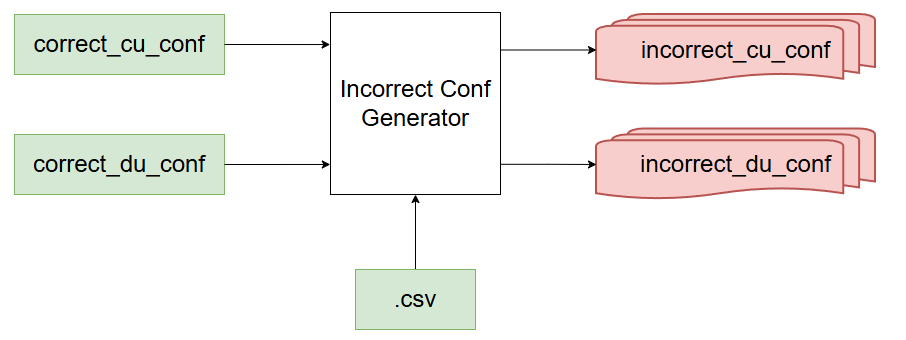